# 06 Faithfulness Evaluator

**Project:** LLMOps Monitoring & Evaluation Platform

**Notebook:** `06-faithfulness-evaluator.ipynb`

In [1]:
# Start coding here
# ==========================================
# Notebook 06
# Faithfulness Evaluator
# ==========================================

import pandas as pd
import numpy as np

from transformers import pipeline

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv("../data/golden_dataset.csv")

df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN


In [3]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

In [4]:
llm = pipeline(
    "text-generation", model="Qwen/Qwen2.5-1.5B-Instruct", max_new_tokens=256
)

Device set to use cpu


In [5]:
context = """
AWS pricing increased by 8%.

Google Cloud reduced storage costs by 4%.

Azure pricing remained stable.
"""

In [6]:
generated_answer = """
AWS pricing increased by 8%.

Azure pricing increased by 5%.
"""

In [7]:
def extract_claims(text):

    claims = []

    for sentence in text.split("."):

        sentence = sentence.strip()

        if len(sentence) > 5:

            claims.append(sentence)

    return claims

In [8]:
claims = extract_claims(generated_answer)

claims

['AWS pricing increased by 8%', 'Azure pricing increased by 5%']

In [9]:
def semantic_similarity(text1, text2):

    emb1 = embedding_model.encode(text1)

    emb2 = embedding_model.encode(text2)

    score = cosine_similarity(emb1.reshape(1, -1), emb2.reshape(1, -1))[0][0]

    return float(score)

In [10]:
def split_context(context):

    chunks = []

    for item in context.split("."):

        item = item.strip()

        if len(item) > 5:

            chunks.append(item)

    return chunks

In [11]:
context_chunks = split_context(context)

context_chunks

['AWS pricing increased by 8%',
 'Google Cloud reduced storage costs by 4%',
 'Azure pricing remained stable']

In [12]:
def verify_claim(claim, context_chunks):

    scores = []

    for chunk in context_chunks:

        similarity = semantic_similarity(claim, chunk)

        scores.append(similarity)

    return max(scores)

In [13]:
verify_claim("AWS pricing increased by 8%", context_chunks)

1.0

In [14]:
verify_claim("Azure pricing increased by 5%", context_chunks)

0.6971911787986755

In [15]:
def faithfulness_score(answer, context, threshold=0.75):

    claims = extract_claims(answer)

    context_chunks = split_context(context)

    verified = 0

    claim_scores = []

    for claim in claims:

        score = verify_claim(claim, context_chunks)

        claim_scores.append(score)

        if score >= threshold:

            verified += 1

    final_score = verified / max(len(claims), 1)

    return {
        "faithfulness": round(final_score, 4),
        "claims": len(claims),
        "verified_claims": verified,
        "claim_scores": claim_scores,
    }

In [16]:
faithfulness_score(generated_answer, context)

{'faithfulness': 0.5,
 'claims': 2,
 'verified_claims': 1,
 'claim_scores': [1.0, 0.6971911787986755]}

In [17]:
def extract_claims_llm(answer):

    prompt = f"""
Extract factual claims.

Answer:

{answer}

Return one claim per line.
"""

    result = llm(prompt)

    return result[0]["generated_text"]

In [18]:
extract_claims_llm(generated_answer)

'\nExtract factual claims.\n\nAnswer:\n\n\nAWS pricing increased by 8%.\n\nAzure pricing increased by 5%.\n\n\nReturn one claim per line.\nClaim: AWS pricing increased by 8%. \nClaim: Azure pricing increased by 5%.'

In [19]:
faithfulness_results = []

In [20]:
for _, row in df.iterrows():

    result = faithfulness_score(row["generated_response"], row["contexts"])

    faithfulness_results.append(result)

In [21]:
faithfulness_df = pd.DataFrame(
    {
        "faithfulness": [r["faithfulness"] for r in faithfulness_results],
        "claims": [r["claims"] for r in faithfulness_results],
        "verified_claims": [r["verified_claims"] for r in faithfulness_results],
    }
)

In [22]:
faithfulness_df.head()

,faithfulness,claims,verified_claims
0,1.0,1,1
1,1.0,1,1
2,1.0,1,1
3,1.0,1,1
4,1.0,1,1


In [23]:
evaluation_df = pd.concat([df, faithfulness_df], axis=1)

In [24]:
evaluation_df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length,faithfulness,claims,verified_claims
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0,1.0,1,1
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0,1.0,1,1
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0,1.0,1,1
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN,1.0,1,1
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN,1.0,1,1


In [25]:
def faithfulness_label(score):

    if score >= 0.90:
        return "Excellent"

    elif score >= 0.75:
        return "Good"

    elif score >= 0.50:
        return "Average"

    return "Poor"

In [26]:
evaluation_df["faithfulness_quality"] = evaluation_df["faithfulness"].apply(
    faithfulness_label
)

In [27]:
evaluation_df[["question", "faithfulness", "faithfulness_quality"]]

,question,faithfulness,faithfulness_quality
0,What is AWS?,1.0,Excellent
1,What is Azure?,1.0,Excellent
2,What is Google Cloud?,1.0,Excellent
3,What is AWS?,1.0,Excellent
4,What is Azure?,1.0,Excellent
5,What is Google Cloud?,1.0,Excellent
6,What is Oracle Cloud?,1.0,Excellent
7,What is IBM Cloud?,1.0,Excellent
8,Question 8,0.0,Poor
9,Question 9,0.0,Poor


In [28]:
import matplotlib.pyplot as plt

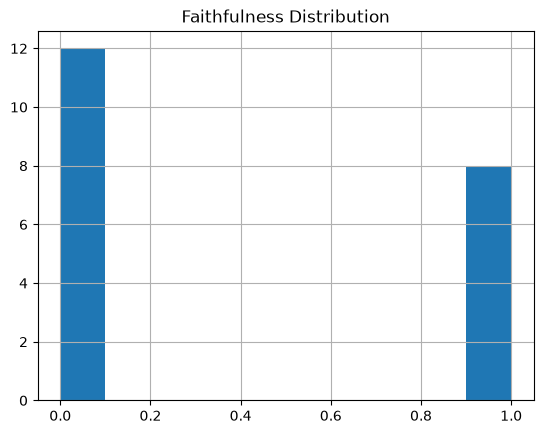

In [29]:
evaluation_df["faithfulness"].hist(bins=10)

plt.title("Faithfulness Distribution")

plt.show()

In [31]:
hallucinations = evaluation_df[evaluation_df["faithfulness"] < 0.70]

In [32]:
hallucinations[["question", "generated_response", "faithfulness"]]

,question,generated_response,faithfulness
8,Question 8,Sample generated response,0.0
9,Question 9,Sample generated response,0.0
10,Question 10,Sample generated response,0.0
11,Question 11,Sample generated response,0.0
12,Question 12,Sample generated response,0.0
13,Question 13,Sample generated response,0.0
14,Question 14,Sample generated response,0.0
15,Question 15,Sample generated response,0.0
16,Question 16,Sample generated response,0.0
17,Question 17,Sample generated response,0.0


In [33]:
evaluation_df.to_csv("../evaluation_results/faithfulness_results.csv", index=False)